# Row 9: A positive close means lower realized volatility over the next week

| field | content |
|---|---|
| frequency (GEX period) | daily print |
| strength | 0.42 Spearman correlation |
| tradability (1 to 10) | 5 |
| holds for | yes SPY, QQQ (-0.32); weak IWM, AAPL, AMZN, MSFT (-0.15 to -0.27); no NVDA, TSLA, META, AMD |
| how to trade | the same filter at the weekly options horizon |
| numbers (SPY) | 5-day forward volatility 9.8% versus 14.7%, p-value below 0.001 |
| example | 25 November to 11 December 2025 positive episode: volatility 8.1% versus 15.1% in the 20 days before |
| video opener | The same hedging reading works for the week ahead, not only tomorrow: after a positive gamma close, realized volatility over the next five days runs about a third lower than after a negative one. If you trade weekly options, that is the difference between selling premium into a calm week and buying protection before a rough one. |

In [1]:
import sys
import json
import warnings
import numpy as np
import pandas as pd
warnings.filterwarnings("ignore")
sys.path.insert(0, "../gex_history")
import rows as R
import gexlib as G
pd.set_option("display.width", 220); pd.set_option("display.max_columns", 40)
ctx = R.load("spy")
print(ctx["sym"], len(ctx["daily"]), "days")

SPY 751 days


,n_pos,n_neg,mean_pos,mean_neg,median_pos,median_neg,diff,ci_lo,ci_hi,p_mwu,expectation
test,,,,,,,,,,,
forward vol,316,430,0.0984,0.1474,0.0885,0.1283,-0.049,-0.0608,-0.0381,0.0,lower in +GEX


{
 "tercile_fvol": {
  "bottom third": 0.17066145486529805,
  "top third": 0.09914072285329627,
  "p": 8.954612836153525e-25
 },
 "spearman_gex_fvol": -0.4189654166985519
}


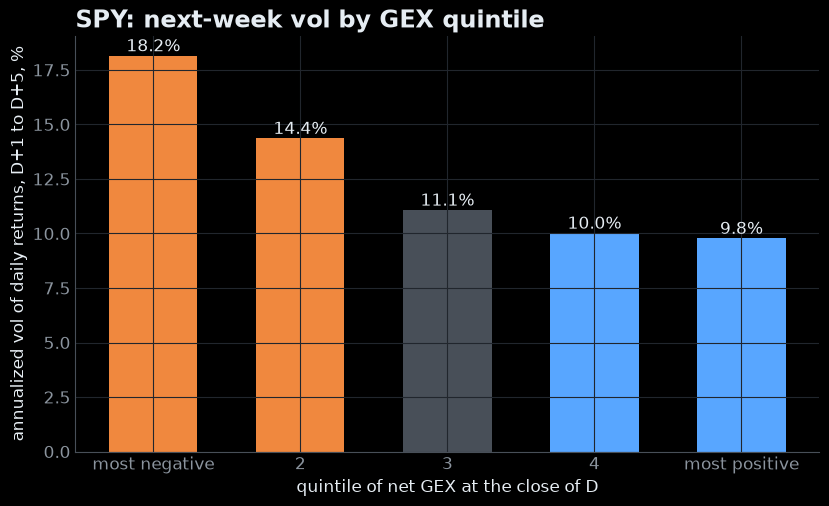

In [2]:
res = R.row9(ctx)
display(res['sign_cut'].drop(columns=['outcome']).round(4))
print(json.dumps({k: v for k, v in R.show(res).items() if k != 'sign_cut'}, indent=1))
_ = R.fig9(ctx, res, G.FIGURES / 'row09_next_week_vol.png')

In [3]:
R.per_name({'r9_fvol_top_third': '5-day volatility, own top third', 'r9_fvol_bottom_third': 'own bottom third', 'r9_spearman_gex_fvol': 'Spearman correlation'}).round(3)

,"5-day volatility, own top third",own bottom third,Spearman correlation
symbol,,,
SPY,0.099,0.171,-0.419
QQQ,0.149,0.208,-0.323
IWM,0.163,0.202,-0.242
NVDA,0.334,0.367,-0.081
TSLA,0.458,0.463,0.066
AAPL,0.178,0.245,-0.229
AMZN,0.242,0.333,-0.265
META,0.353,0.380,-0.124
MSFT,0.230,0.303,-0.151
